# 1 — Preprocessing for MONAI and nnU-Net

**Research software — not for clinical use.**

This notebook is for a professor or reviewer who wants to *see* how a CT is prepared before the two Version-1 models look at it. You do not need Docker or a GPU. All files are already in this `release` branch (`data/demo/`).

| Model | How it sees the scan | Locked-test Dice |
|---|---|---|
| **MONAI** | 2.5D: three neighbouring slices → predict the middle slice | 0.257 |
| **nnU-Net** | Full 3D volume (it resamples internally) | 0.455 |

**Same intensity recipe for both.** Only the *geometry* differs.

Inference (what the website does) is summarised at the end in plain language. This notebook does **not** train a model and does **not** run the slow nnU-Net predictor.

## 0. Setup

Run cells in order. From either the repo root or `notebooks/`.

In [1]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import nibabel as nib
import yaml

cwd = Path.cwd().resolve()
if (cwd / "config" / "preprocessing.yaml").is_file():
    ROOT = cwd
elif (cwd.parent / "config" / "preprocessing.yaml").is_file():
    ROOT = cwd.parent
else:
    raise FileNotFoundError("Run this notebook from the repo root or notebooks/")

src = ROOT / "src"
if str(src) not in sys.path:
    sys.path.insert(0, str(src))

DEMO = ROOT / "data" / "demo"
CT = DEMO / "01_all_classes" / "all_classes.nii.gz"
GT = DEMO / "ground_truth" / "01_all_classes" / "all_classes.nii.gz"
MANIFEST = DEMO / "MANIFEST.csv"
CFG = ROOT / "config" / "preprocessing.yaml"

LABELS = {0: "background", 1: "EDH", 2: "SDH", 3: "SAH", 4: "IPH", 5: "IVH"}
COLORS = {1: "#e74c3c", 2: "#f1c40f", 3: "#2ecc71", 4: "#3498db", 5: "#9b59b6"}

print("project:", ROOT)
print("demo CT:", CT.exists(), CT.name)
print("expert mask:", GT.exists())


project: C:\Users\1016f\OneDrive\Desktop\BrainHemorrhageAI-release
demo CT: True all_classes.nii.gz
expert mask: True


## 1. Exploratory look at the demo set

The public clone ships **17** research CTs, not the full BHSD 192.  
`all_classes.nii.gz` is the only BHSD case that has **all five** hemorrhage types.

In [2]:
manifest = pd.read_csv(MANIFEST)
print("demo scans:", len(manifest))
print()
print("How many subtypes per scan?")
print(manifest["n_subtypes"].value_counts().sort_index().to_string())
print()
display(manifest[["group", "filename", "subtypes", "total_mL", "EDH_mL", "SDH_mL", "SAH_mL", "IPH_mL", "IVH_mL"]])


demo scans: 17

How many subtypes per scan?
n_subtypes
1    5
2    3
3    2
4    6
5    1



,group,filename,subtypes,total_mL,EDH_mL,SDH_mL,SAH_mL,IPH_mL,IVH_mL
0,all_classes,all_classes.nii.gz,EDH SDH SAH IPH IVH,47.832,0.420,6.709,0.315,18.820,21.569
1,four_classes,four_classes_SDH_SAH_IPH_IVH_1.nii.gz,SDH SAH IPH IVH,260.023,0.000,76.875,28.257,76.767,78.125
2,four_classes,four_classes_SDH_SAH_IPH_IVH_4.nii.gz,SDH SAH IPH IVH,88.328,0.000,33.027,7.238,5.896,42.166
3,four_classes,four_classes_SDH_SAH_IPH_IVH_2.nii.gz,SDH SAH IPH IVH,154.741,0.000,5.998,4.390,75.294,69.060
4,four_classes,four_classes_EDH_SDH_SAH_IPH_1.nii.gz,EDH SDH SAH IPH,76.087,10.762,58.183,2.248,4.894,0.000
5,four_classes,four_classes_EDH_SDH_SAH_IPH_2.nii.gz,EDH SDH SAH IPH,33.052,16.654,9.279,2.050,5.069,0.000
6,four_classes,four_classes_SDH_SAH_IPH_IVH_3.nii.gz,SDH SAH IPH IVH,129.253,0.000,32.045,64.878,30.425,1.905
7,EDH,EDH_1.nii.gz,EDH,133.324,133.324,0.000,0.000,0.000,0.000
8,EDH,EDH_2.nii.gz,EDH,38.581,38.581,0.000,0.000,0.000,0.000
9,SDH,SDH_2.nii.gz,SDH,31.683,0.000,31.683,0.000,0.000,0.000


**How to read that table.** `total_mL` is expert hemorrhage volume. A scan can be “EDH only” (one class) or a mix. Volume is what a clinician often asks first: *how much blood?*

In [3]:
nii = nib.load(str(CT))
mask = nib.load(str(GT))
hu = nii.get_fdata().astype(np.float32)
gt = np.rint(mask.get_fdata()).astype(np.int64)
spacing = tuple(float(z) for z in nii.header.get_zooms()[:3])
voxel_ml = (spacing[0] * spacing[1] * spacing[2]) / 1000.0

print("shape (x, y, z):", hu.shape)
print("voxel spacing mm:", tuple(round(s, 3) for s in spacing))
print("HU min / max:", float(hu.min()), float(hu.max()))
print("HU mean / std:", float(hu.mean()), float(hu.std()))
print()
print("Expert labels present:")
for lab in range(6):
    n = int(np.sum(gt == lab))
    if n == 0:
        continue
    print(f"  {lab} {LABELS[lab]:12}  {n:8d} voxels   {n * voxel_ml:7.2f} mL")


shape (x, y, z): (512, 512, 33)
voxel spacing mm: (0.488, 0.488, 5.0)
HU min / max: -1024.0 1776.0
HU mean / std: -587.8012084960938 554.40380859375

Expert labels present:
  0 background     8610628 voxels   10264.67 mL
  1 EDH                352 voxels      0.42 mL
  2 SDH               5628 voxels      6.71 mL
  3 SAH                264 voxels      0.31 mL
  4 IPH              15787 voxels     18.82 mL
  5 IVH              18093 voxels     21.57 mL


**EDA takeaway.** CT values are Hounsfield units (HU). Bone is very bright; air is very dark; acute blood sits in a narrower band. If we feed raw HU to a network, bone and air dominate. That is why we clip.

## 2. Locked intensity preprocessing

From `config/preprocessing.yaml` (Wu et al., BHSD):

1. **Clip** HU to **[-40, 120]** — keep brain and acute blood; drop extreme bone / air.
2. **Normalize** as **(HU − 40) / 80** — a fixed z-score, not a statistic we re-estimate on each scan.
3. **Do not resample here.** Spacing stays native so milliliters stay honest. nnU-Net may resample *inside* its own trainer; we still report volume on the original grid.

MONAI and nnU-Net **share this intensity path**. We do not invent a second window for the strong model.

In [4]:
cfg = yaml.safe_load(CFG.read_text(encoding="utf-8"))
print(yaml.safe_dump(cfg, sort_keys=False))

from preprocessing.preprocess_volume import (
    apply_intensity_clip,
    apply_normalization,
    resolve_clip_bounds,
)

lo, hi = resolve_clip_bounds(cfg)
clipped = apply_intensity_clip(hu, lo, hi)
normed = apply_normalization(clipped, cfg)
print(f"clip bounds: [{lo}, {hi}]")
print(f"after clip  min/max: {clipped.min():.1f} / {clipped.max():.1f}")
print(f"after norm  min/max: {normed.min():.3f} / {normed.max():.3f}")
print("native shape unchanged:", hu.shape == clipped.shape == normed.shape)


window_level: 40
window_width: 80
clip_min: -40
clip_max: 120
normalization_method: zscore
train_mean: 40
train_std: 80
disk_cache_enabled: true
disk_cache_dir: data/processed/volume_cache
memory_cache_entries: 16

clip bounds: [-40.0, 120.0]


after clip  min/max: -40.0 / 120.0
after norm  min/max: -1.000 / 1.000
native shape unchanged: True


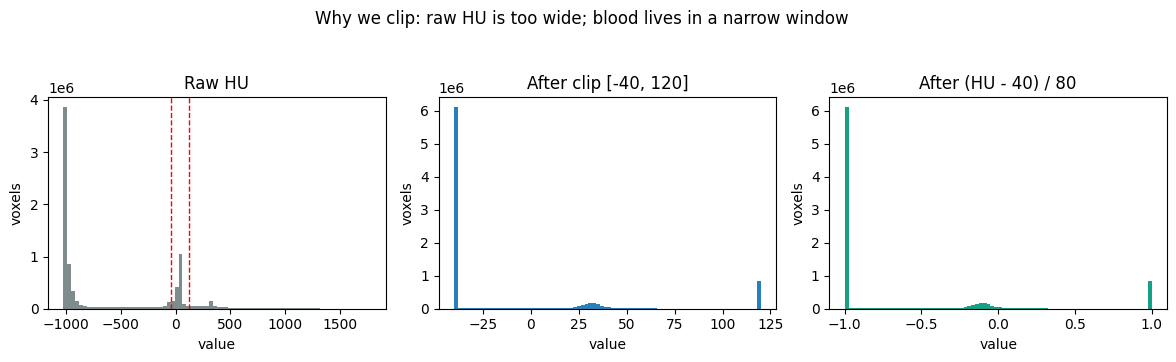

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
axes[0].hist(hu.ravel(), bins=80, color="#7f8c8d")
axes[0].set_title("Raw HU")
axes[0].axvline(-40, color="red", ls="--", lw=1)
axes[0].axvline(120, color="red", ls="--", lw=1)
axes[1].hist(clipped.ravel(), bins=80, color="#2980b9")
axes[1].set_title("After clip [-40, 120]")
axes[2].hist(normed.ravel(), bins=80, color="#16a085")
axes[2].set_title("After (HU - 40) / 80")
for ax in axes:
    ax.set_xlabel("value")
    ax.set_ylabel("voxels")
fig.suptitle("Why we clip: raw HU is too wide; blood lives in a narrow window", y=1.05)
plt.tight_layout()
plt.show()


## 3. What a slice looks like

We pick the axial slice with the most expert hemorrhage so the overlay is easy to see.

largest-bleed slice index: 24 of 33


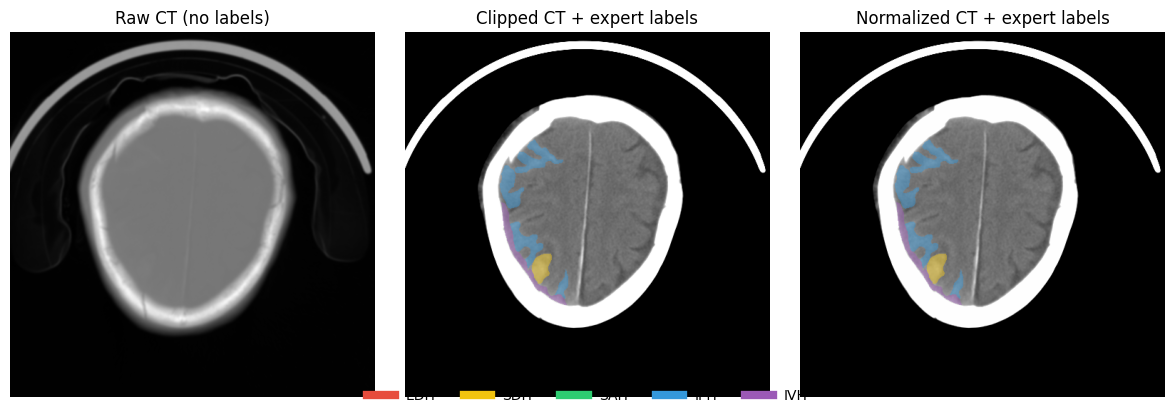

In [6]:
# axial axis is z (index 2)
bleed = (gt > 0).sum(axis=(0, 1))
z = int(np.argmax(bleed))
print("largest-bleed slice index:", z, "of", hu.shape[2])

def show_rgb(base, overlay_mask, title, ax):
    sl = base[:, :, z]
    sl = (sl - sl.min()) / (sl.max() - sl.min() + 1e-6)
    rgb = np.stack([sl, sl, sl], axis=-1)
    color_layer = np.zeros_like(rgb)
    for lab, col in COLORS.items():
        hexcol = col.lstrip("#")
        rgb_c = np.array([int(hexcol[i:i+2], 16) / 255 for i in (0, 2, 4)])
        sel = overlay_mask[:, :, z] == lab
        color_layer[sel] = rgb_c
    mix = np.where(overlay_mask[:, :, z][..., None] > 0, 0.55 * rgb + 0.45 * color_layer, rgb)
    ax.imshow(np.rot90(mix), origin="lower")
    ax.set_title(title)
    ax.axis("off")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
show_rgb(hu, np.zeros_like(gt), "Raw CT (no labels)", axes[0])
show_rgb(clipped, gt, "Clipped CT + expert labels", axes[1])
show_rgb(normed, gt, "Normalized CT + expert labels", axes[2])
fig.legend(
    handles=[plt.Line2D([0], [0], color=COLORS[i], lw=6, label=LABELS[i]) for i in range(1, 6)],
    loc="lower center",
    ncol=5,
    frameon=False,
)
plt.tight_layout()
plt.show()


**Colour key:** EDH red · SDH yellow · SAH green · IPH blue · IVH purple.

The expert drawing is what Dice compares against later. The model never sees this mask at demo time — only the CT.

## 4. How MONAI uses the volume (2.5D)

MONAI does **not** swallow the whole 3D cube at once. For each axial slice `i` it stacks:

`[slice i−1, slice i, slice i+1]` → 3 channels → 2D U-Net → labels for **slice i**.

Edges repeat the first/last slice. After every slice is predicted, we stack them back into a 3D mask and compute mL with the **original** spacing.

2.5D sample shape (channels, x, y): (3, 512, 512)


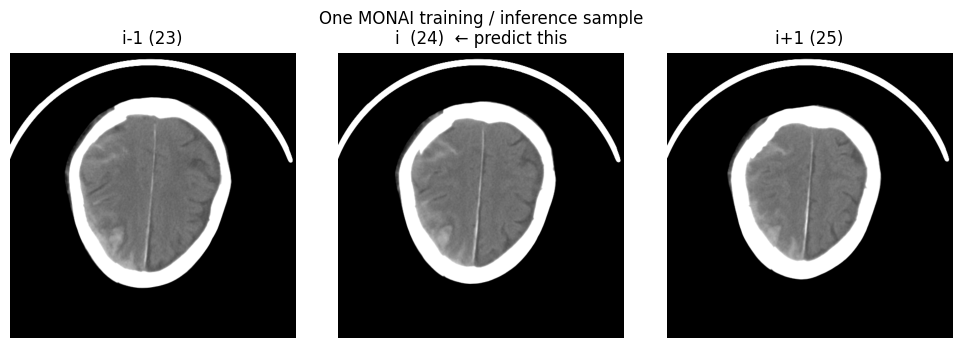

In [7]:
i = z
prev_i, next_i = max(0, i - 1), min(hu.shape[2] - 1, i + 1)
triplet = np.stack([normed[:, :, prev_i], normed[:, :, i], normed[:, :, next_i]], axis=0)
print("2.5D sample shape (channels, x, y):", triplet.shape)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
for ax, sl, name in zip(axes, triplet, [f"i-1 ({prev_i})", f"i  ({i})  ← predict this", f"i+1 ({next_i})"]):
    ax.imshow(np.rot90(sl), cmap="gray", origin="lower")
    ax.set_title(name)
    ax.axis("off")
fig.suptitle("One MONAI training / inference sample")
plt.tight_layout()
plt.show()


## 5. How nnU-Net uses the same CT (3D)

nnU-Net receives the **whole volume**. It plans its own patch size and resampling. We still:

- start from the same clipped / normalized intensity idea
- map predictions back to the **native grid**
- report volume with the original voxel size

That is why nnU-Net is slower on CPU (~5+ minutes) and usually more accurate on overlap (Dice 0.455 vs 0.257).

## 6. Inference — brief, for a non-technical reader

You do **not** need to run this cell to understand the product. The website does the work.

**What “inference” means here.** The trained model looks at a new CT it was not tuned on and draws the five hemorrhage types.

**What you see in the UI**

1. Upload a `.nii.gz` from `data/demo/`.
2. Pick **MONAI** (about 20 seconds) or **nnU-Net** (minutes).
3. The app returns an overlay, a volume in mL, and a research confidence number.

**What the numbers mean** (same 29 locked test cases, never used in training)

| | MONAI | nnU-Net |
|---|---|---|
| Overlap with expert (Dice) | 0.257 | **0.455** |
| Volume error (mean) | 19.5 mL | **14.3 mL** |
| Wait on a laptop CPU | ~20 s | ~5+ min |

Higher Dice is a better drawing. Lower volume error is a better millilitre count.

**What this is not.** It is not a diagnosis, not a triage tool, and the confidence score is **not** a clinical probability.

To actually run inference, use Docker — see the root `README.md`. This notebook stops at *how the CT is prepared*.

## 7. One-sentence summary

We clip the CT to a brain/blood window, scale it with a fixed formula, keep the original millimetre grid for volume, then either feed **three slices** to MONAI or the **full 3D** volume to nnU-Net.